### In the DataView.ipynb, the data will be explored to showcase: ###
**1. Statistical Data Integrity** (null entries & data types)

**2. Class Distribution & Dataset Balance** (label frequencies & bias verification),  

**3. Pixel Spatial Re-constitution & Visual Profiling** (2D matrix reshaping, handwriting variations, and intensity validation).

## Step 1: Import crucial libraries. ##

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt

## Step 2: Show Datassets folder structure. ##

In [2]:
def show_all_tree(path, indent=""):
    if not os.path.exists(path):
        return print(f"Not found: {path}")

    print(f"{indent}├── 📁 {os.path.basename(os.path.abspath(path))}/")
    for item in sorted(os.listdir(path)):
        full_path = os.path.join(path, item)
        if os.path.isdir(full_path):
            show_all_tree(full_path, indent + "│   ")
        else:
            print(f"{indent}│   ├── 📄 {item}")

show_all_tree("../Datasets")

├── 📁 Datasets/
│   ├── 📁 Test/
│   │   ├── 📁 Letter/
│   │   │   ├── 📁 English/
│   │   │   │   ├── 📄 A_Z Handwritten Data_Test01.csv
│   │   │   │   ├── 📄 A_Z Handwritten Data_Test02.csv
│   │   │   │   ├── 📄 A_Z Handwritten Data_Test03.csv
│   │   │   │   ├── 📄 A_Z Handwritten Data_Test04.csv
│   │   │   │   ├── 📄 A_Z Handwritten Data_Test05.csv
│   │   │   ├── 📁 Vietnamese/
│   │   │   │   ├── 📄 Viet_dataset_01.csv
│   │   │   │   ├── 📄 Viet_dataset_02.csv
│   │   │   │   ├── 📄 Viet_dataset_03.csv
│   │   │   │   ├── 📄 Viet_dataset_04.csv
│   │   │   │   ├── 📄 Viet_dataset_05.csv
│   │   │   │   ├── 📄 Viet_dataset_06.csv
│   │   │   │   ├── 📄 Viet_dataset_07.csv
│   │   │   │   ├── 📄 Viet_dataset_08.csv
│   │   │   │   ├── 📄 Viet_dataset_09.csv
│   │   │   │   ├── 📄 Viet_dataset_10.csv
│   │   │   │   ├── 📄 Viet_dataset_11.csv
│   │   │   │   ├── 📄 Viet_dataset_12.csv
│   │   │   │   ├── 📄 Viet_dataset_13.csv
│   │   │   │   ├── 📄 Viet_dataset_14.csv
│   │   │   │   ├── 📄 Viet_data

## Step 3: EDA ##

In [4]:
file_text_english = "../Datasets/Train/Letters/English/A_Z Handwritten Data_02.csv"
file_text_viet = "../Datasets/Train/Letters/Vietnamese/Viet_dataset_01.csv"
file_number = "../Datasets/Train/Numbers/mnist_train_1.csv"


In [5]:
#-- READ ENGLISH TEXT DATASET. --#
print(f"Reading English text dataset from: {file_text_english}")
#-- CALCULATE INFORMATION. --#
df_label = pd.read_csv(file_text_english, header=None, usecols=[0])
total_samples = len(df_label)
total_classes = df_label[0].nunique()  # Cột đầu tiên lúc này có index là 0
#-- pRINT RESULT. --#
print(f"Information about the dataset {os.path.basename(file_text_english)}:")
print(f"Total images:  {total_samples:,}")
print(f"Total samples: {total_samples:,}")
print(f"Total classes: {total_classes} classes")


Reading English text dataset from: ../Datasets/Train/Letters/English/A_Z Handwritten Data_02.csv
Information about the dataset A_Z Handwritten Data_02.csv:
Total images:  15,001
Total samples: 15,001
Total classes: 3 classes


In [6]:
#-- READ VIETNAMESE TEXT DATASET. --#
print(f"Reading Vietnamese text dataset from: {file_text_viet}")
#-- CALCULATE INFORMATION. --#
df_label = pd.read_csv(file_text_viet, header=None, usecols=[0])
total_samples = len(df_label)
total_classes = df_label[0].nunique()  
#-- pRINT RESULT. --#
print(f"Information about the dataset {os.path.basename(file_text_viet)}:")
print(f"Total images:  {total_samples:,}")
print(f"Total samples: {total_samples:,}")
print(f"Total classes: {total_classes} classes")


Reading Vietnamese text dataset from: ../Datasets/Train/Letters/Vietnamese/Viet_dataset_01.csv
Information about the dataset Viet_dataset_01.csv:
Total images:  2,501
Total samples: 2,501
Total classes: 383 classes


In [7]:
#-- READ NUMBER DATASET. --#
print(f"Reading number dataset from: {file_number}")
#-- CALCULATE INFORMATION. --#
df_label = pd.read_csv(file_number, header=None, usecols=[0])
total_samples = len(df_label)
total_classes = df_label[0].nunique()  
#-- pRINT RESULT. --#
print(f"Information about the dataset {os.path.basename(file_number)}:")
print(f"Total images:  {total_samples:,}")
print(f"Total samples: {total_samples:,}")
print(f"Total classes: {total_classes} classes")


Reading number dataset from: ../Datasets/Train/Numbers/mnist_train_1.csv
Information about the dataset mnist_train_1.csv:
Total images:  10,001
Total samples: 10,001
Total classes: 21 classes


C:\Users\DELL\AppData\Local\Temp\ipykernel_9564\2728311264.py:4: DtypeWarning: Columns (0: 0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_label = pd.read_csv(file_number, header=None, usecols=[0])


In [8]:
df_label = pd.read_csv(file_text_english, header=None, usecols=[0])
df_label.columns = ["label"]
df_label["label"] = df_label["label"].astype(str)

stats_df = df_label["label"].value_counts().reset_index()
stats_df.columns = ["label", "count"]
stats_df["percentage"] = (stats_df["count"] / stats_df["count"].sum()) * 100

print("All data has been finished! Prepare for the next step: Data Visualization.")

All data has been finished! Prepare for the next step: Data Visualization.


In [9]:
dataset_dir = "../Datasets/Train/Letters/English"
file_paths = sorted(
    glob.glob(os.path.join(dataset_dir, "A_Z Handwritten Data_*.csv"))
)

alphabet_images = {}
print("Scanning Files...")

if not file_paths:
    print(f"❌ Not Found: {dataset_dir}")
else:
    for file_path in file_paths:
        if len(alphabet_images) == 26:
            break

        print(f"📂 Checking File: {os.path.basename(file_path)}")

        chunk_size = 5000
        for chunk in pd.read_csv(file_path, chunksize=chunk_size):
            labels = chunk.iloc[:, 0].values
            pixels = chunk.iloc[:, 1:].values

            for idx in range(len(labels)):
                lbl = int(labels[idx]) 

                if 0 <= lbl <= 25 and lbl not in alphabet_images:
                    alphabet_images[lbl] = pixels[idx].reshape(28, 28)

                if len(alphabet_images) == 26:
                    break
            if len(alphabet_images) == 26:
                break

    print(
        f"\n Scanning Complete! Collected {len(alphabet_images)}/26 letters from the actual data."
    )

Scanning Files...
📂 Checking File: A_Z Handwritten Data_01.csv
📂 Checking File: A_Z Handwritten Data_02.csv
📂 Checking File: A_Z Handwritten Data_03.csv
📂 Checking File: A_Z Handwritten Data_04.csv
📂 Checking File: A_Z Handwritten Data_05.csv
📂 Checking File: A_Z Handwritten Data_06.csv
📂 Checking File: A_Z Handwritten Data_07.csv
📂 Checking File: A_Z Handwritten Data_08.csv
📂 Checking File: A_Z Handwritten Data_09.csv
📂 Checking File: A_Z Handwritten Data_10.csv
📂 Checking File: A_Z Handwritten Data_11.csv
📂 Checking File: A_Z Handwritten Data_12.csv
📂 Checking File: A_Z Handwritten Data_13.csv
📂 Checking File: A_Z Handwritten Data_14.csv
📂 Checking File: A_Z Handwritten Data_15.csv
📂 Checking File: A_Z Handwritten Data_16.csv
📂 Checking File: A_Z Handwritten Data_17.csv
📂 Checking File: A_Z Handwritten Data_18.csv
📂 Checking File: A_Z Handwritten Data_19.csv
📂 Checking File: A_Z Handwritten Data_20.csv

 Scanning Complete! Collected 20/26 letters from the actual data.


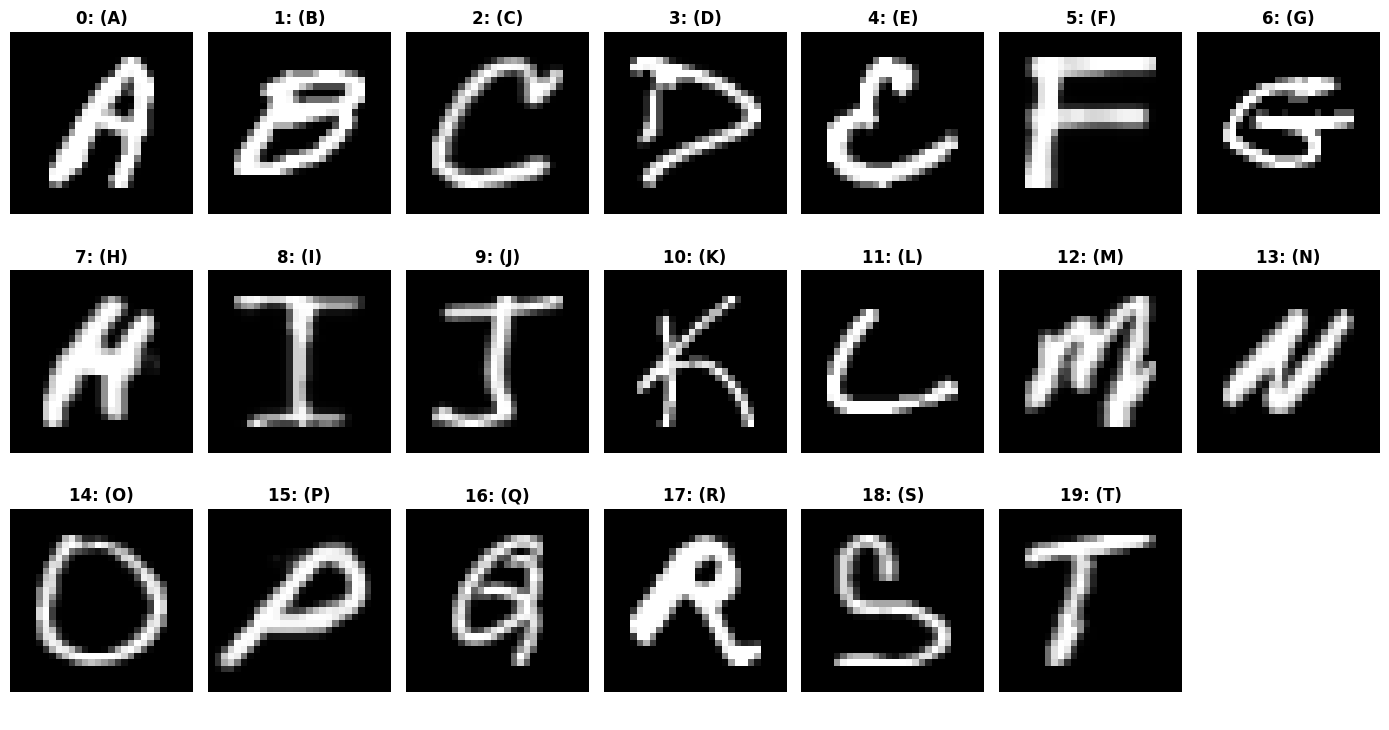

In [10]:
if "alphabet_images" in locals() and len(alphabet_images) > 0:
    sorted_labels = sorted(alphabet_images.keys())
    total_found = len(sorted_labels)

    n_cols = 7
    n_rows = (total_found + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.5 * n_rows))

    def get_char_name(label_num):
        return chr(65 + label_num)

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for i in range(n_rows * n_cols):
        row_idx = i // n_cols
        col_idx = i % n_cols
        ax = axes[row_idx, col_idx]

        if i < total_found:
            lbl = sorted_labels[i]
            char_name = get_char_name(lbl)
            img_matrix = alphabet_images[lbl]

            ax.imshow(img_matrix, cmap="gray")
            ax.set_title(f"{lbl}: ({char_name})", fontsize=12, fontweight="bold")

        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(
        "Error"
    )

In [16]:
dataset_dir = "../Datasets/Train/Numbers"  
file_paths = sorted(glob.glob(os.path.join(dataset_dir, "mnist_train_*.csv")))

number_images = {}
print("Scanning Number Files...")

if not file_paths:
    print(f"Error: There's any file in the folder directory: {dataset_dir}")
    print("Recommendation: Please check your directory path.")
else:
    for file_path in file_paths:
        if len(number_images) == 10:
            break

        print(f"📂 Checking File: {os.path.basename(file_path)}")

        chunk_size = 5000
        for chunk in pd.read_csv(file_path, chunksize=chunk_size):
            labels = chunk.iloc[:, 0].values
            pixels = chunk.iloc[:, 1:].values

            for idx in range(len(labels)):
                lbl = int(labels[idx])  
                if 0 <= lbl <= 9 and lbl not in number_images:
                    number_images[lbl] = pixels[idx].reshape(28, 28)
                if len(number_images) == 10:
                    break
            if len(number_images) == 10:
                break

    print(f"Scanning Complete! Collected {len(number_images)}/10 digits from the actual data.")

Scanning Number Files...
📂 Checking File: mnist_train_1.csv
Scanning Complete! Collected 10/10 digits from the actual data.


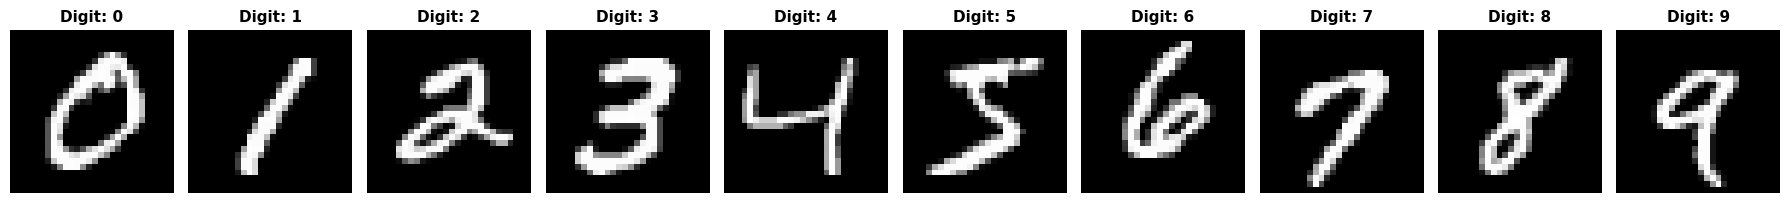

Success!


In [18]:
%matplotlib inline
if "number_images" in locals() and len(number_images) > 0:
    sorted_digits = sorted(list(number_images.keys()))
    total_found = len(sorted_digits)

    fig, axes = plt.subplots(1, 10, figsize=(18, 2.5))
    if total_found == 1:
        axes = [axes]

    for idx, lbl in enumerate(sorted_digits):
        ax = axes[idx]
        img_matrix = number_images[lbl]

        ax.imshow(img_matrix, cmap="gray")
        ax.set_title(f"Digit: {lbl}", fontsize=11, fontweight="bold")

        ax.axis("off")
    for j in range(total_found, 10):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
    print(
        f"Success!"
    )
else:
    print(
        "Error: No digit images found to display."
    )